In [1]:
####################################
#ENVIRONMENT SETUP

In [2]:
#LIBRARIES

#system
import os
import sys

#math and array operations
import numpy as np
import math
import pandas as pd

#data classes
import xarray as xr

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#loading bar
from tqdm import tqdm

In [3]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis","MPAS_Model_Data"))
from CLASSES_Directories import DirectoryManager_Class

In [4]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "Observation_Data", "TRACER")
dataType = "RadarData"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER/RadarData



In [5]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [6]:
def GetSimulationTime(RunType):
    if (RunType[0] == "TRACER") and (RunType[1] == "MOIST"):
        SimulationTime = ("2022-06-30","2022-07-03")
    return SimulationTime

RunType = ("TRACER","MOIST","NSSL")
SimulationTime = GetSimulationTime(RunType)
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

Found 289/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/history_cartesian/history.2022-06-30_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/diag_cartesian/diag.2022-06-30_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           MOIST
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-30 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:289
 # Diag Files:   289
 # Time Steps:   289
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL
 Static File:    TRACER_regional5250_scaled3_x20.835586.static.latlon.nc



In [7]:
########################
#DATA INFORMATION

In [8]:
#DATA CITATION
# Atmospheric Radiation Measurement (ARM) user facility. 2021. X-Band Scanning ARM Cloud Radar (XSACRCFRQC), 2022-06-09 to 2022-07-02, ARM Mobile Facility (HOU) Houston, TX; AMF1 (main site for TRACER) (M1). Compiled by Y. Feng, A. Matthews, E. Schuman, K. Johnson, I. Lindenmaier, V. Castro and T. Wendler. ARM Data Center. Data set accessed 2025-11-05 at http://dx.doi.org/10.5439/2001296.

#Globus Download Link
# https://urldefense.com/v3/__https://app.globus.org/file-manager?origin_id=ba87aabe-30f6-433d-b4a5-19434c595e0f&origin_path=*rosemana1*261781*__;Ly8v!!PvDODwlR4mBZyAb0!REKAOzHJNvJk50CY5Pjl135CV83BhArwtdyMDuBM-28KqreBug8Xb5Mc3MLgy_p9PUiWe2uVXq-EfUtLcGdH5w$

In [9]:
#DATA CITATION
# Atmospheric Radiation Measurement (ARM) user facility. 2021. Ka-Band Scanning ARM Cloud Radar (KASACRCFRQC), 2022-06-08 to 2022-07-02, ARM Mobile Facility (HOU) Houston, TX; AMF1 (main site for TRACER) (M1). Compiled by I. Lindenmaier, K. Johnson, D. Nelson, A. Matthews, T. Wendler, V. Melo de Castro, M. Rocque and Y. Feng. ARM Data Center. Data set accessed 2025-11-05 at http://dx.doi.org/10.5439/1877338.

# https://armgov.svcs.arm.gov/capabilities/instruments/kasacr

#Globus Download Link
#https://urldefense.com/v3/__https://app.globus.org/file-manager?origin_id=ba87aabe-30f6-433d-b4a5-19434c595e0f&origin_path=*rosemana1*261893*__;Ly8v!!PvDODwlR4mBZyAb0!UJrKWg_xaYuaaa_iaY91TCVMB_neSskXsDKHtPPCG7Ix6sEmiEvnngTUrYuV18LudZqxB3eHyTDuCHSZ3o3zrg$

In [14]:
#LOADING RADAR CLASS

fileDirectory = "/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/ARM_XBandRadar_Data/ppiv/"
radarDataType = "X-Band"
RadarData_XBand = RadarData_ARM_Class(fileDirectory,radarDataType)

fileDirectory = "/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/ARM_KBandRadar_Data/ppiv/"
radarDataType = "K-Band"
RadarData_KBand = RadarData_ARM_Class(fileDirectory,radarDataType)

RadarData_MRMS = RadarData_MRMS_Class(ModelData,
                                      fileDirectory=os.path.join(DirectoryManager.dataDirectory,
                                                                 "Observation_Data/TRACER/MRMS_RadarData",
                                                                 f"{ModelData.simulationDates[0]}_{ModelData.simulationDates[-1]}"))

In [15]:
##########################
#ORIGINAL RADAR DATA

In [16]:
#GETTING DATA
target_time = datetime(2022, 7, 1, 0, 0, 0)

#TRACER X-Band Radar
index, _ = RadarData_XBand.FindClosestFileIndex(RadarData_XBand.fileList, target_time)
filePath_XBand = RadarData_XBand.filePathList[index]
radar_XBand = RadarData_XBand.GetRadarData(filePath_XBand)

#TRACER K-Band Radar
index, _ = RadarData_KBand.FindClosestFileIndex(RadarData_KBand.fileList, target_time)
filePath_KBand = RadarData_KBand.filePathList[index]
radar_KBand = RadarData_KBand.GetRadarData(filePath_KBand)

Loaded radar file at 2022-07-01 16:29:36 UTC
Loaded radar file at 2022-07-01 16:29:33 UTC


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
RadarData_XBand.PlotReflectivity(axis=axes[0])
RadarData_KBand.PlotReflectivity(axis=axes[1])

In [18]:
##########################
#MRMS RADAR DATA

In [19]:
target = datetime(2022, 7, 1, 0, 0)  # 2022-07-01 00:00 UTC
radarData_t, nearestFilePath = RadarData_MRMS.LoadClosestMRMSFile(target_time)

Target time:  2022-07-01 00:00:00
Closest file: MRMSReflectivity_CONUS_TRACER_20220701-000042.nc (2022-07-01 00:00:42)


<GeoAxes: title={'center': 'MRMS Reflectivity – 2022-07-01 00:00:42 – 1 km'}>

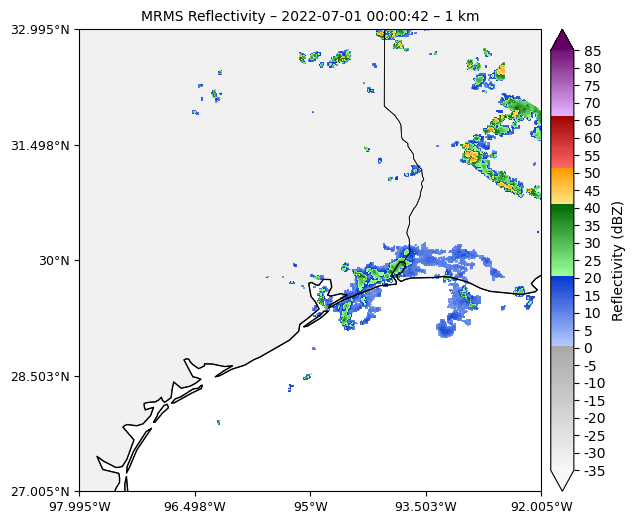

In [374]:
fig, axes = RadarPlotting_Class.CreateMapAxes(nrows=1,ncols=1,
                                              figsize=(12,6))
axis = axes[0,0]
lat = radarData_t['latitude'].data
lon = radarData_t['longitude'].data-360
RadarPlotting_Class.PlotReflectivity(axis, lat,lon,radarData_t,dataName="MRMS")

In [ ]:
##########################
#GRIDDED RADAR DATA

In [83]:
# #LOADING DATA
# grid_XBand, data_XBand = RadarData_XBand.GridRadarReflectivity(radar_XBand)
# grid_KBand, data_KBand = RadarData_XBand.GridRadarReflectivity(radar_KBand)

In [85]:
# #PLOTTING DATA

# fig, axes = plt.subplots(1, 2, figsize=(12,4))
# RadarData_XBand.PlotGriddedReflectivity(grid_XBand,data_XBand, axis=axes[0])
# RadarData_KBand.PlotGriddedReflectivity(grid_KBand,data_KBand, axis=axes[1])